<a href="https://colab.research.google.com/github/sumukhveeramalla/cs666student/blob/main/CS666_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

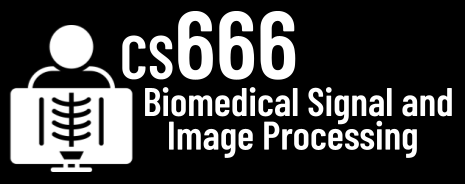

# Assignment 1

In [1]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


**Task 1** (5 pts): Install the BioSPPY library with the following code.

In [2]:
!pip install biosppy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 6.2 MB/s eta 0:00:00


**Task 2** (10 pts): Download a sample ecg dataset from https://cs666.org/data/ecg.txt and upload it to this colab. The following code loads the dataset. Note: this might fail with an import error, but should be an easy fix :)

In [3]:
!pip install peakutils

In [4]:
from biosppy import storage
signal, metadata = storage.load_txt('ecg.txt')

**Task 3** (10 pts): Figure out the sampling rate for this data and how many seconds it lasts.

In [5]:
metadata

{'sampling_rate': 1000.0, 'resolution': 12, 'labels': ['ECG']}

sampling rate from meta data is 1000.

In [6]:
signal

array([2044., 2044., 2044., ..., 2044., 2045., 2043.])

In [7]:
signal_length = len(signal)
signal_length

15000

Length of signal is 15000.

seconds = signal length / sampling rate

In [8]:
SAMPLING_RATE = 1000 ### TODO!
SECONDS = signal_length/SAMPLING_RATE ### TODO!

In [9]:
SAMPLING_RATE

1000

In [10]:
SECONDS

15.0

**Task 4** (15 pts): Process the signal with BioSPPY using the `ecg.ecg` method.

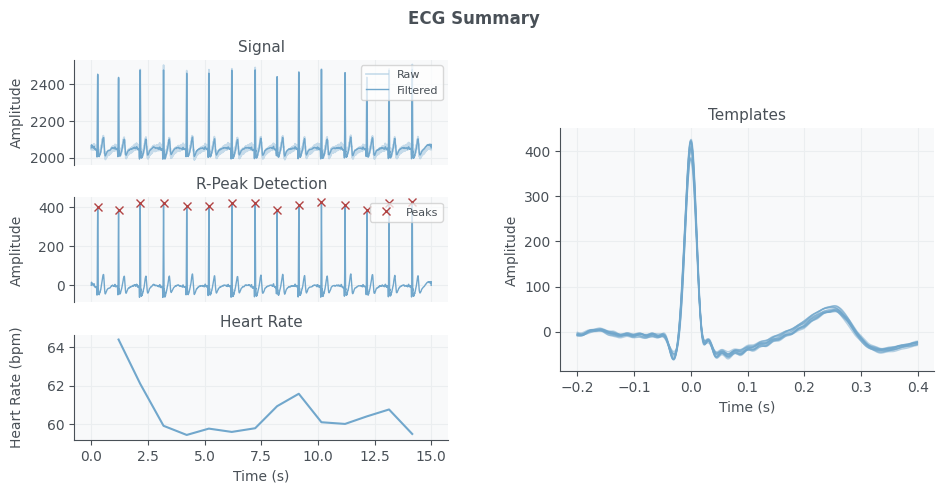

In [11]:
### TODO
from biosppy.signals import ecg

output = ecg.ecg(signal = signal, sampling_rate = SAMPLING_RATE)

**Task 5** (10 pts): Plot the first 3 seconds of the unfiltered signal and then the filtered signal. Can you spot the P, Q, R, S, T waves?

In [12]:
output.keys()

['ts',
 'filtered',
 'rpeaks',
 'templates_ts',
 'templates',
 'heart_rate_ts',
 'heart_rate']

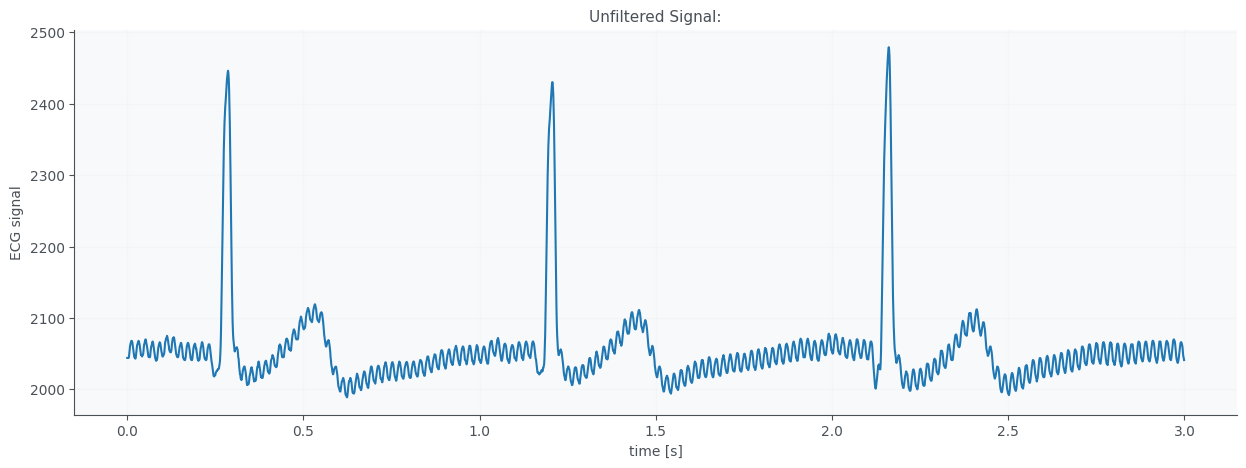

In [13]:
### TODO plot unfiltered signal
import matplotlib.pyplot as plt

first_3_secs = int(3*SAMPLING_RATE)
ts = output['ts']
plt.figure(figsize=(15, 5))
plt.plot(ts[:first_3_secs],signal[:first_3_secs])
plt.title("Unfiltered Signal:")
plt.xlabel('time [s]')
plt.ylabel('ECG signal')
plt.grid(True,alpha=0.3)
plt.show()


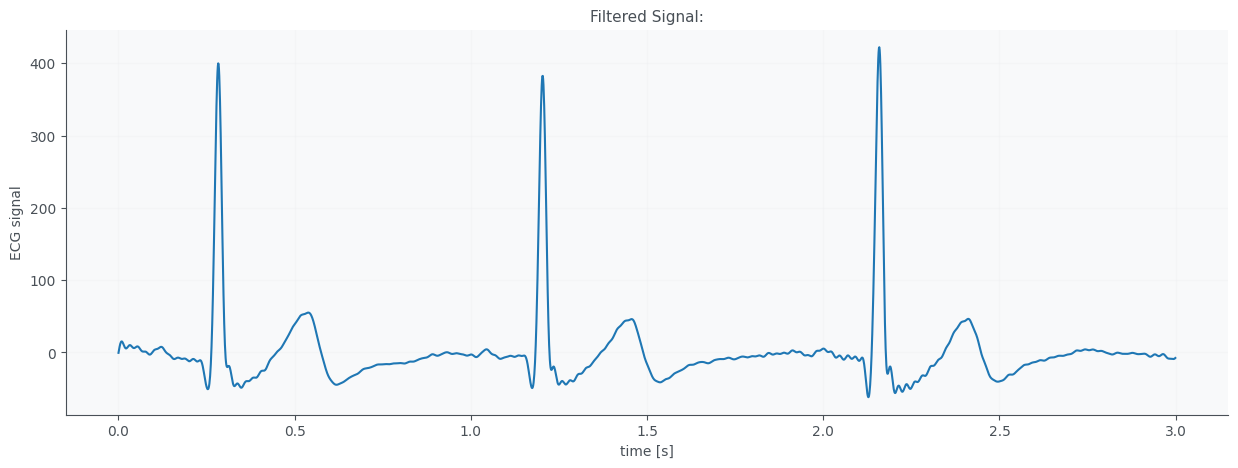

In [14]:
### TODO plot filtered signal
filtered = output['filtered']
plt.figure(figsize=(15, 5))
plt.plot(ts[:first_3_secs],filtered[:first_3_secs])
plt.title("Filtered Signal:")
plt.xlabel('time [s]')
plt.ylabel('ECG signal')
plt.grid(True,alpha=0.3)
plt.show()

Yes we can spot P,Q,R,S,T waves here.

**Task 6** (15 pts): Please plot the whole filtered signal and mark the r-peaks with vertical lines based on the ecg.ecg output. You can use `plt.axvline(x = 100, color = 'r', ls=':')` to create a red, dashed vertical line at position 100. Please label the x-axis as 'time [s]'.

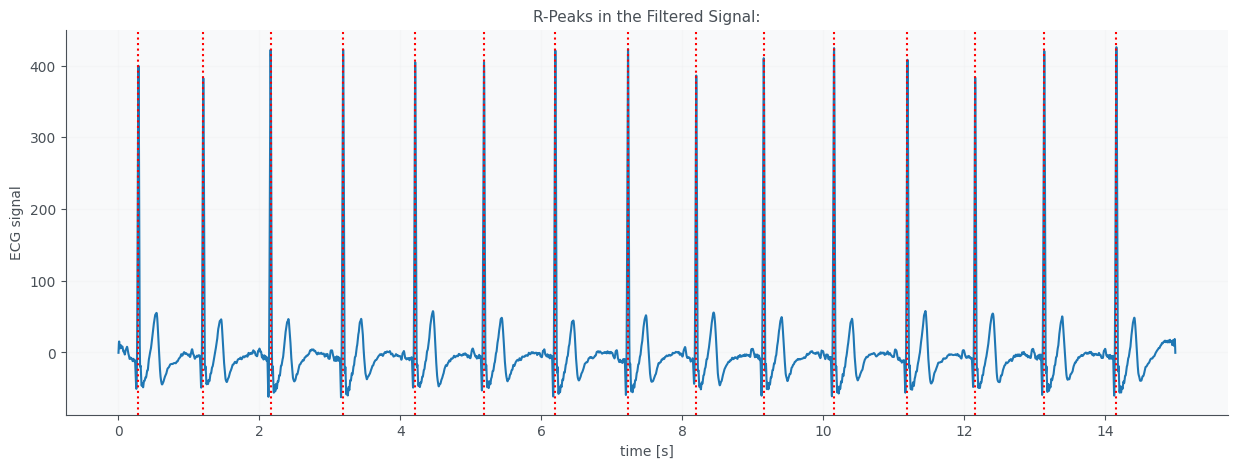

In [15]:
### TODO
plt.figure(figsize=(15, 5))
plt.plot(ts,filtered)
for rpeak in output['rpeaks']:
  plt.axvline(x = ts[rpeak], color = 'r', ls=':')
plt.title("R-Peaks in the Filtered Signal:")
plt.xlabel('time [s]')
plt.ylabel('ECG signal')
plt.grid(True,alpha=0.3)
plt.show()

**Task 7** (5 pts): Let's install the NeuroKit2 library.

In [16]:
!pip install neurokit2
import neurokit2 as nk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 17.0 MB/s eta 0:00:00


**Task 8** (20 pts): Detect P Q S T Peaks using Neurokit.

dict_keys(['ECG_P_Peaks', 'ECG_P_Onsets', 'ECG_P_Offsets', 'ECG_Q_Peaks', 'ECG_R_Onsets', 'ECG_R_Offsets', 'ECG_S_Peaks', 'ECG_T_Peaks', 'ECG_T_Onsets', 'ECG_T_Offsets'])

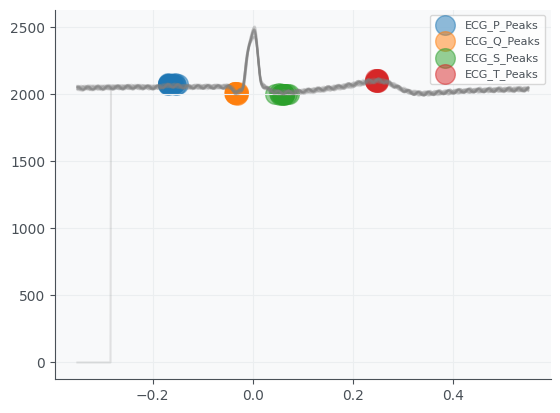

In [17]:
# We know the R spikes now but what about P Q S T waves?
# TODO Can you use nk.ecg_delineate to detect them in the unfiltred signal?
# Hint: Look at the tutorial: https://neuropsychology.github.io/NeuroKit/examples/ecg_delineate/ecg_delineate.html
# Hint 2: The plot will have blue, orange, green, and red circles :)
# Hint 3: rpeaks were detected above from biosppy's ecg.ecg method

signals, info = nk.ecg_delineate(signal, rpeaks=output['rpeaks'], sampling_rate = SAMPLING_RATE, method="dwt", show=True, show_type='peaks')
info.keys()

In [18]:
# TODO Does the detection work well?

{
    'P_peaks': len(info.get('ECG_P_Peaks',[])),
    'Q_peaks': len(info.get('ECG_Q_Peaks',[])),
    'R_peaks': len(info.get('ECG_R_Peaks',[])),
    'S_peaks': len(info.get('ECG_S_Peaks',[])),
    'T_peaks': len(info.get('ECG_T_Peaks',[]))
}

{'P_peaks': 15, 'Q_peaks': 15, 'R_peaks': 0, 'S_peaks': 15, 'T_peaks': 15}

Yes Detection went well.

**Task 9** (10 pts): Use the sleepecg library to find the R Peaks.

In [19]:
# We have the R spikes/peaks now from Biosppy from above but there is another
# library called sleepecg.
# TODO Please install it and run the rpeak detection!
# Docs: https://sleepecg.readthedocs.io/en/stable/

!pip install sleepecg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.6/419.6 kB 13.4 MB/s eta 0:00:00


In [20]:
import sleepecg

from sleepecg import detect_heartbeats

rpeaks_sleep = detect_heartbeats(signal, fs=SAMPLING_RATE)

In [21]:
rpeaks_biosppy = output['rpeaks']

In [23]:
# TODO Do Biosppy and sleepecg give different rpeaks? Please calculate the MSE!

import numpy as np
n = np.min([len(rpeaks_sleep), len(rpeaks_biosppy)])

mse = np.mean((np.array(rpeaks_sleep[:n]) - np.array(rpeaks_biosppy[:n]))**2)
mse

np.float64(0.2)

**Bonus Task** (33 pts): Detect P Q S T Peaks for the full signal before and after filtering.

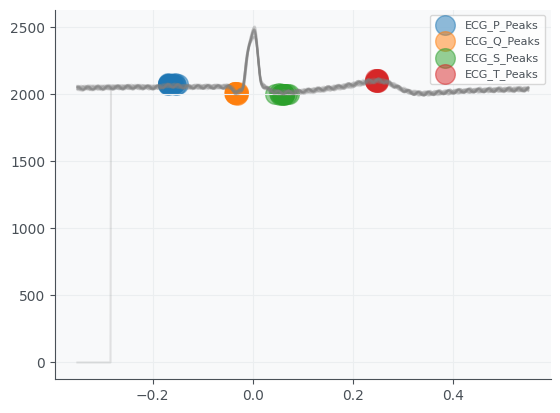

In [24]:
# TODO As above use the nk.ecg_delineate function to detect peaks for the whole signal
signals_full, info_full = nk.ecg_delineate(signal, rpeaks=output['rpeaks'], sampling_rate=SAMPLING_RATE, method='dwt', show=True, show_type='peaks')

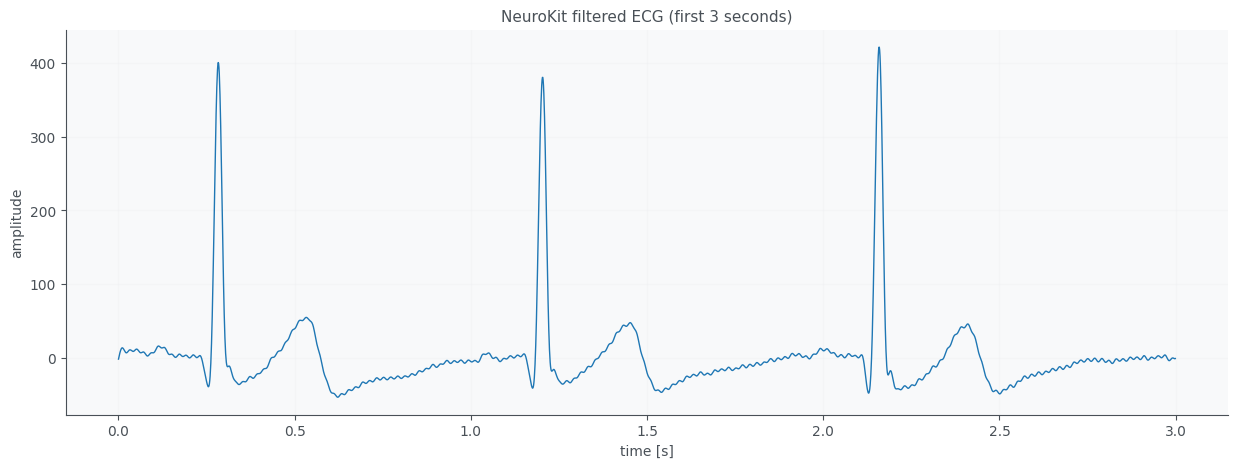

In [25]:
# TODO Let's filter the signal and see if the detection improves.
# Hint: You can use nk.signal_filter to define a bandpass.
# Hint 2: Which lowcut and highcut frequencies work well? Play with it :)
# Hint 3: You don't need to re-calculate the rpeaks since they are pretty accurate in general.

filtered_nk = nk.signal_filter(signal, sampling_rate=SAMPLING_RATE, lowcut=0.5, highcut=40, method='butterworth', order=4)

plt.figure(figsize=(15, 5))
plt.plot(ts[:first_3_secs], filtered_nk[:first_3_secs], lw=1)
plt.title('NeuroKit filtered ECG (first 3 seconds)')
plt.xlabel('time [s]')
plt.ylabel('amplitude')
plt.grid(True, alpha=0.3)
plt.show()

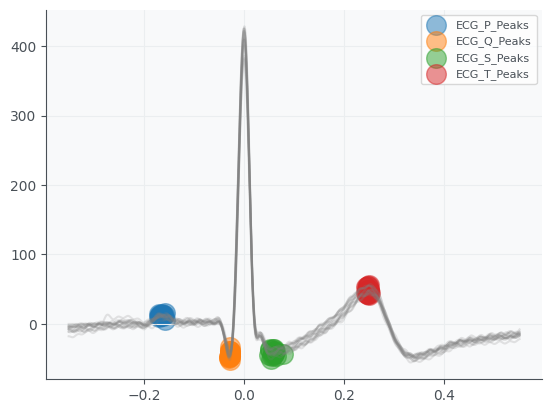

In [26]:
# Finally, run the delineation on the filtered signal from BioSPPY.
signals_filtered, info_filtered = nk.ecg_delineate(filtered_nk, rpeaks=output['rpeaks'], sampling_rate=SAMPLING_RATE, method='dwt', show=True, show_type='peaks')

In [27]:
# TODO Which one works the best?
{
    'unfiltered': {
        'P': len(info_full.get('ECG_P_Peaks', [])),
        'Q': len(info_full.get('ECG_Q_Peaks', [])),
        'R': len(info_full.get('ECG_R_Peaks', [])),
        'S': len(info_full.get('ECG_S_Peaks', [])),
        'T': len(info_full.get('ECG_T_Peaks', [])),
    },
    'filtered': {
        'P': len(info_filtered.get('ECG_P_Peaks', [])),
        'Q': len(info_filtered.get('ECG_Q_Peaks', [])),
        'R': len(info_filtered.get('ECG_R_Peaks', [])),
        'S': len(info_filtered.get('ECG_S_Peaks', [])),
        'T': len(info_filtered.get('ECG_T_Peaks', [])),
    }
}

{'unfiltered': {'P': 15, 'Q': 15, 'R': 0, 'S': 15, 'T': 15},
 'filtered': {'P': 15, 'Q': 15, 'R': 0, 'S': 15, 'T': 15}}

filtered data works better.

In [28]:
#
# Great job!!
#
#  , ; ,   .-'"""'-.   , ; ,
#  \\|/  .'         '.  \|//
#   \-;-/   ()   ()   \-;-/
#   // ;               ; \\
#  //__; :.         .; ;__\\
# `-----\'.'-.....-'.'/-----'
#        '.'.-.-,_.'.'
#jgs       '(  (..-'
#            '-'
#